# `mu_to_H0` — TRGB Distance Ladder Demo

This notebook measures H0 from **TRGB** distance moduli to calibrator SN host galaxies.
It is the TRGB counterpart of [`demo_mu_to_H0.ipynb`](demo_mu_to_H0.ipynb) (the Cepheid version)
and uses the **same solver** (`mu_to_H0.py`, unchanged).

**Concept:**
The distance ladder runs first-rung distances (TRGB here) → calibrator SNe → Hubble-flow SNe.
`mu_to_H0` takes the first/second rung as a *user input* (TRGB distance moduli μ to each host)
and fits the Hubble-flow SNe to recover H0 and M_B, using the full SN covariance matrix.

**TRGB dataset** (shipped with the repo, built by `data/build_TRGB_partial.py`):
- `data/TRGB_y.npy` — SN magnitude observables
- `data/TRGB_C.npy` — SN covariance matrix
- `data/TRGB_labels.csv` — row metadata (label, type, host)

It covers **40 calibrator hosts**: all 37 SH0ES R22 hosts plus the three CATS-only hosts
NGC 1316, NGC 1404, NGC 4526 (Hoyt et al. 2023). To rebuild or modify the selection,
run [`prep_TRGB_data.ipynb`](prep_TRGB_data.ipynb).

> ⚠️ **Input distances are placeholders.** `data/TRGB_distances.csv` is a placeholder. Replace it with your own TRGB distance table.

*Demonstration/learning purpose only — do not use for cosmological analysis.*

## 1. Load TRGB second- and third-rung SN data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mu_to_H0 import solve_H0, calibrator_hosts

# TRGB-track SN dataset (40 calibrator hosts, CATS-style Hubble-flow selection).
# Built by data/build_TRGB_partial.py (or interactively in prep_TRGB_data.ipynb).
y      = np.load('data/TRGB_y.npy')
C      = np.load('data/TRGB_C.npy')
labels = pd.read_csv('data/TRGB_labels.csv')

cal = labels[labels['type'] == 'CAL']
hf  = labels[labels['type'] == 'HF']
print(f'Loaded {len(y)} SN rows: {len(cal)} calibrator obs, {len(hf)} Hubble-flow SNe, '
      f'{cal["host"].nunique()} calibrator hosts.')

Loaded 578 SN rows: 82 calibrator obs, 496 Hubble-flow SNe, 40 calibrator hosts.


# What's in the ```y``` (observable) vector?

## Hubble's law:
The Hubble constant is defined in units of velocity per distance (km/s/Mpc). We combine that with the definition of distance moduli and a multi-order approximation for the redshift-velocity relation:
$$
\begin{cases}
H_0 \equiv v [\mathrm{km/s}] \cdot d^{-1} [\mathrm{Mpc}] & \\
\mu \equiv m - M = 5\log_{10}\frac{d}{10} \\
z \approx v/c & (z\ll 1; \text{see, e.g., Visser 2004 and Riess+22 for higher order terms})
\end{cases}
$$

Rewriting the first term in parsecs and taking a log,
$$5\log_{10} H_0 = 5\log_{10}(cz) - \left(m - M\right) + 25\ .$$

The $v$--$z$ relation can be expanded into higher order terms to account for acceleration, etc., often written in the literature as $\log_{10}cz\{\}$. This gives a system of equations:
$$
\begin{cases}
    \mu_\mathrm{host} = \left(m_\mathrm{SN,\ calib} - M_\mathrm{SN}\right)  & \mathrm{(calibrator\ rung)} \\
    5\log_{10} H_0 = 5\log_{10}\left[c\cdot\{z_\mathrm{HF}+\mathcal{O}(z^2)+\cdots\}\right] - \left(m_\mathrm{SN,\ HF} - M\right) + 25 & \mathrm{(Hubble\text{-}flow\ rung)}
\end{cases}
$$
which we rewrite as
$$
\begin{cases}
    m_\mathrm{SN,\ calib} &= \mu_\mathrm{host} + M_\mathrm{SN} & \mathrm{(calibrator\ rung)} \\
    m_\mathrm{SN,\ HF} - 5\log_{10}cz\{\} - 25 &= M_\mathrm{SN} - 5\log_{10} H_0 & \mathrm{(Hubble\text{-}flow\ rung)}
\end{cases}\ .
$$
The LHS are observed quantities held in the ```y``` vector; covariances between them are in the matrix ```C```. The first-rung distance $\mu_\mathrm{host}$ — from TRGB here, or Cepheids in the companion notebook — enters as a known input. Covariances between rungs are omitted here for simplicity.

## 2. Provide TRGB distance moduli and uncertainties

The host distance moduli are read from **`data/TRGB_distances.csv`**, which has columns
`host, mu, sigma_mu` (an optional `tip_contrast` column is also accepted). Any calibrator host
not listed — or listed with a blank `mu` — is set to NaN and **automatically dropped from the
fit** (its calibrator SNe are down-weighted in the covariance, see `solve_H0`).

Per-host distance errors are fully correlated across all SNe in the same host and are
propagated into the fit covariance automatically.

In [2]:
# Read user-supplied TRGB distances. Start from all calibrator hosts = NaN so that
# any host missing from the CSV is dropped from the fit automatically.
all_hosts = calibrator_hosts(labels)
mu_host       = {h: np.nan for h in all_hosts}
sigma_mu_host = {}

trgb = pd.read_csv('data/TRGB_distances.csv')
unknown = []
for _, row in trgb.iterrows():
    h = str(row['host']).lower()
    if h not in mu_host:
        unknown.append(h)
        continue
    mu = row['mu']
    if pd.isna(mu):
        continue                       # blank -> leave as NaN (dropped)
    mu_host[h] = float(mu)
    sig = row.get('sigma_mu', np.nan)
    if not pd.isna(sig):
        sigma_mu_host[h] = float(sig)  # only finite uncertainties are passed on

measured = [h for h, v in mu_host.items() if not np.isnan(v)]
dropped  = [h for h, v in mu_host.items() if np.isnan(v)]
if unknown:
    print(f"Ignored {len(unknown)} CSV row(s) not in the calibrator list: {unknown}")
print(f"{len(measured)} host(s) used in the fit.")
print(f"{len(dropped)} host(s) dropped (blank/missing distance): {dropped}")

37 host(s) used in the fit.
3 host(s) dropped (blank/missing distance): ['n1316', 'n1404', 'n4526']


## 3. Solve for H0

In [3]:
# NOTE: the uncertainty is approximate -- it does not account for covariance between host distances.
result = solve_H0(mu_host, sigma_mu_host=sigma_mu_host, y=y, C=C, labels=labels)

M_B       = -19.2422 ± 0.0332  mag
H0        = 73.7074 ± 1.1454  km/s/Mpc
chi2/dof  = 490.8/569 = 0.863


## 4. Hubble diagram

Plot the calibrator and Hubble-flow SNe. Redshifts are not stored in the `y` vector
(the cz{} term is already folded in for HF SNe), so the cell below cross-matches Pantheon+
purely to recover redshifts for plotting.

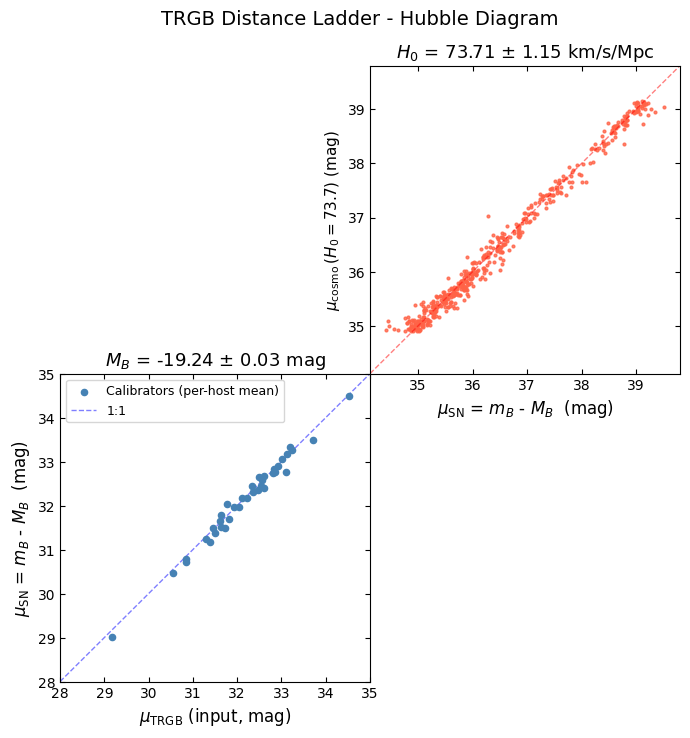

In [4]:
# Cross-match labels with Pantheon+ to recover redshifts (plotting only; uses a copy).
pplus = pd.read_csv('data/Pantheon+SH0ES.dat', sep=r'\s+', comment='#')
pplus['key'] = pplus['CID'].astype(str) + '_' + pplus['IDSURVEY'].astype(str)

labels_plot = labels.copy()
for i in labels_plot.index:
    label = labels_plot.at[i, 'label']
    if not isinstance(label, str):
        continue
    parts = label.split('_')
    if len(parts) == 2:
        labels_plot.at[i, 'CID'], labels_plot.at[i, 'IDSURVEY'] = parts[0], parts[1]
    elif len(parts) == 3:
        labels_plot.at[i, 'CID'], labels_plot.at[i, 'IDSURVEY'] = parts[1], parts[2]
labels_plot['key'] = labels_plot['CID'].astype(str) + '_' + labels_plot['IDSURVEY'].astype(str)

merged = pd.merge(pplus[['key', 'zHD', 'm_b_corr']],
                  labels_plot[['key', 'host', 'type']], on='key', how='inner')
merged_hf  = merged[merged['type'] == 'HF']
merged_cal = merged[merged['type'] == 'CAL']

from astropy.cosmology import LambdaCDM
cosmo = LambdaCDM(H0=result['H0'], Om0=0.3, Ode0=0.7)

fig, axes = plt.subplots(2, 2, figsize=(8, 8))
plt.subplots_adjust(wspace=0, hspace=0)
axes[0, 0].axis('off'); axes[1, 1].axis('off')

# -- mu_SN vs mu_TRGB (calibrators with a measured distance) ------------------
ax = axes[1, 0]
x_vals, y_vals = [], []
for h in merged_cal['host'].dropna().unique():
    if h not in mu_host or np.isnan(mu_host[h]):
        continue
    rows = merged_cal[merged_cal['host'] == h]
    x_vals.append(mu_host[h])
    y_vals.append((rows['m_b_corr'].values - result['M_B']).mean())
ax.scatter(x_vals, y_vals, s=20, color='steelblue', zorder=3, label='Calibrators (per-host mean)')
mu_range = np.linspace(28, 35, 100)
ax.plot(mu_range, mu_range, 'b--', lw=1, alpha=0.5, label='1:1')
ax.set_xlabel(r'$\mu_\mathrm{TRGB}$ (input, mag)', fontsize=12)
ax.set_ylabel(r'$\mu_\mathrm{SN}$ = $m_B$ - $M_B$  (mag)', fontsize=12)
ax.set_title(fr'$M_B$ = {result["M_B"]:.2f} $\pm$ {result["sigma_M_B"]:.2f} mag', fontsize=13)
ax.set_xlim(28, 35); ax.set_ylim(28, 35); ax.legend(fontsize=9)

# -- mu_SN vs mu_cosmo (Hubble-flow) -----------------------------------------
ax2 = axes[0, 1]
hf_mu  = merged_hf['m_b_corr'].values - result['M_B']
hf_z   = merged_hf['zHD'].values
mu_cos = cosmo.distmod(hf_z).value
lim = [min(hf_mu.min(), mu_cos.min()) - 0.3, max(hf_mu.max(), mu_cos.max()) + 0.3]
ax2.scatter(hf_mu, mu_cos, s=4, color='tomato', alpha=0.8)
ax2.plot(lim, lim, 'r--', lw=1, alpha=0.5)
ax2.set_xlim(lim); ax2.set_ylim(lim)
ax2.set_xlabel(r'$\mu_\mathrm{SN}$ = $m_B$ - $M_B$  (mag)', fontsize=12)
ax2.set_ylabel(rf'$\mu_\mathrm{{cosmo}}\,(H_0={result["H0"]:.1f})$ (mag)', fontsize=11)
ax2.set_title(fr'$H_0$ = {result["H0"]:.2f} $\pm$ {result["sigma_H0"]:.2f} km/s/Mpc', fontsize=13)

for a in axes.flatten():
    a.tick_params(direction='in', top=True, right=True)
fig.suptitle('TRGB Distance Ladder - Hubble Diagram', fontsize=14, y=0.95)
plt.show()

## 5. Uniform distance-scale shift

A global bias in the TRGB distance scale (e.g. a TRGB zero-point or NGC 4258 anchor error)
shifts all host distances uniformly. The slope $dH_0/d\Delta\mu \approx -H_0\ln(10)/5 \approx -34$
km/s/Mpc per magnitude, so a ~0.01 mag bias moves $H_0$ by ~0.3 km/s/Mpc.

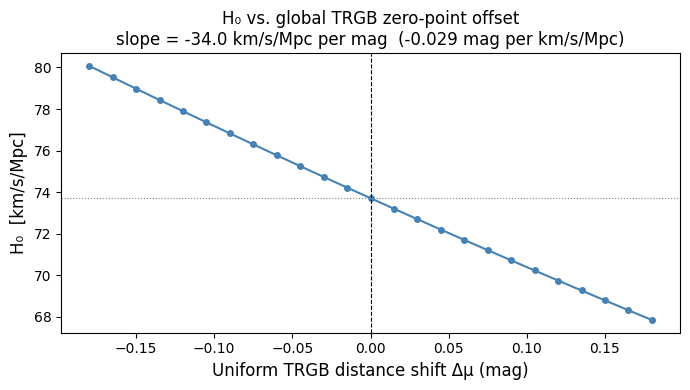

In [5]:
H0_base = result['H0']
shifts  = np.linspace(-0.18, 0.18, 25)
H0_vals = []
for ds in shifts:
    # shift only measured hosts; leave dropped (NaN) hosts dropped
    mu_shifted = {h: (v + ds if not np.isnan(v) else np.nan) for h, v in mu_host.items()}
    r = solve_H0(mu_shifted, sigma_mu_host=sigma_mu_host, y=y, C=C, labels=labels, verbose=False)
    H0_vals.append(r['H0'])

H0_vals = np.array(H0_vals)
slope = np.polyfit(shifts, H0_vals, 1)[0]

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(shifts, H0_vals, 'o-', color='steelblue', markersize=4)
ax.axvline(0, color='k', lw=0.8, ls='--')
ax.axhline(H0_base, color='gray', lw=0.8, ls=':')
ax.set_xlabel('Uniform TRGB distance shift \u0394\u03bc (mag)', fontsize=12)
ax.set_ylabel('H\u2080  [km/s/Mpc]', fontsize=12)
ax.set_title(f'H\u2080 vs. global TRGB zero-point offset\n'
             f'slope = {slope:.1f} km/s/Mpc per mag  ({1/slope:.3f} mag per km/s/Mpc)')
plt.tight_layout()
plt.show()